In [1]:
%matplotlib widget
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
retry_strategy = Retry(
    total=10,
    backoff_factor=1
)
adapter = HTTPAdapter(max_retries=retry_strategy)

In [3]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    response = session.get("http://127.0.0.1:8000/insights/agency/6")
    data = response.json()

In [4]:
insights_by_reference_id = dict()
for insight in data:
    if insight["cfr_reference_id"] not in insights_by_reference_id:
        insights_by_reference_id[insight["cfr_reference_id"]] = list()
    insights_by_reference_id[insight["cfr_reference_id"]].append(insight)

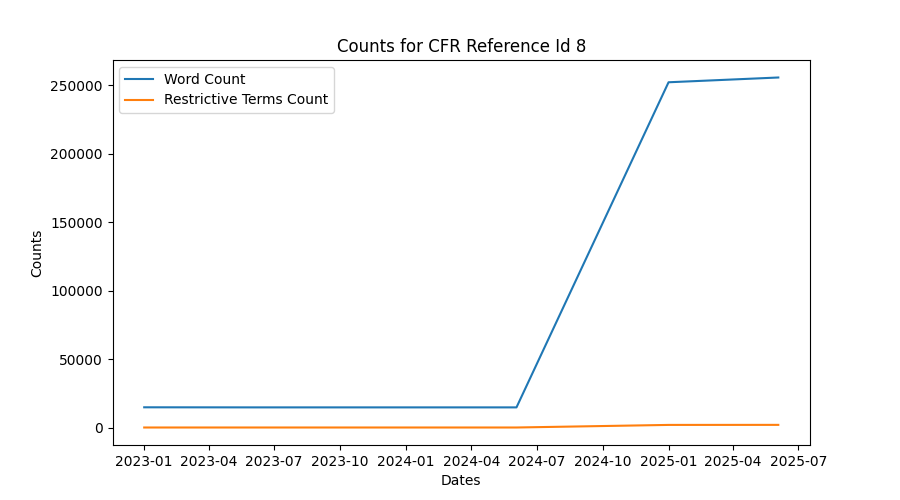

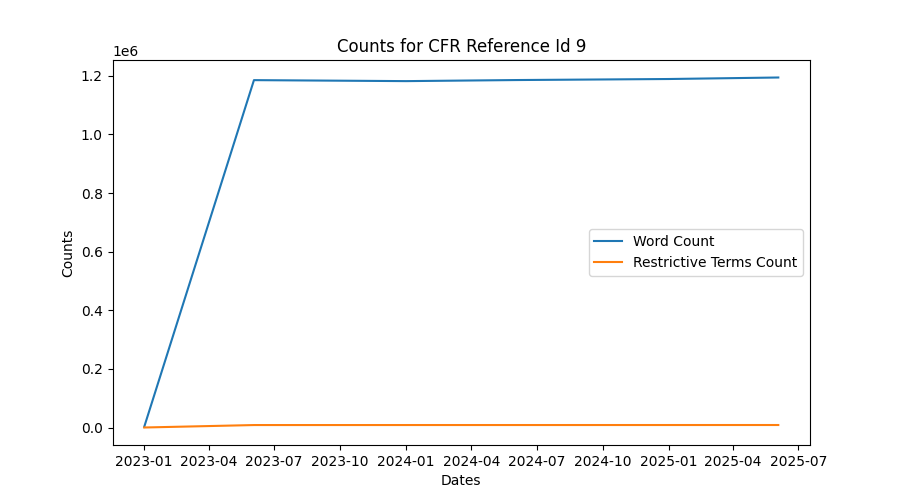

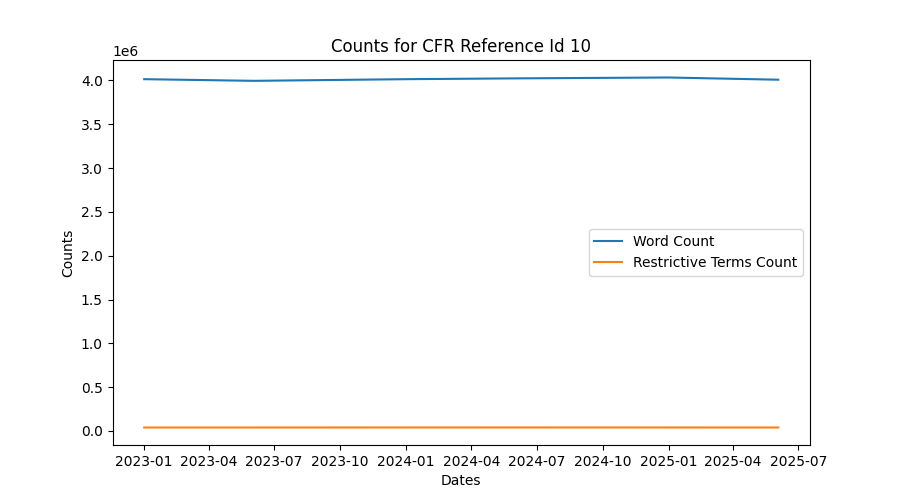

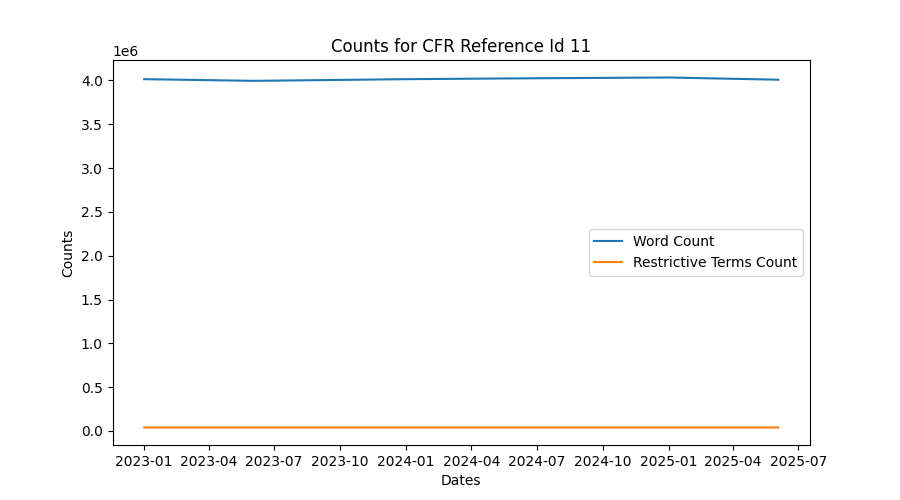

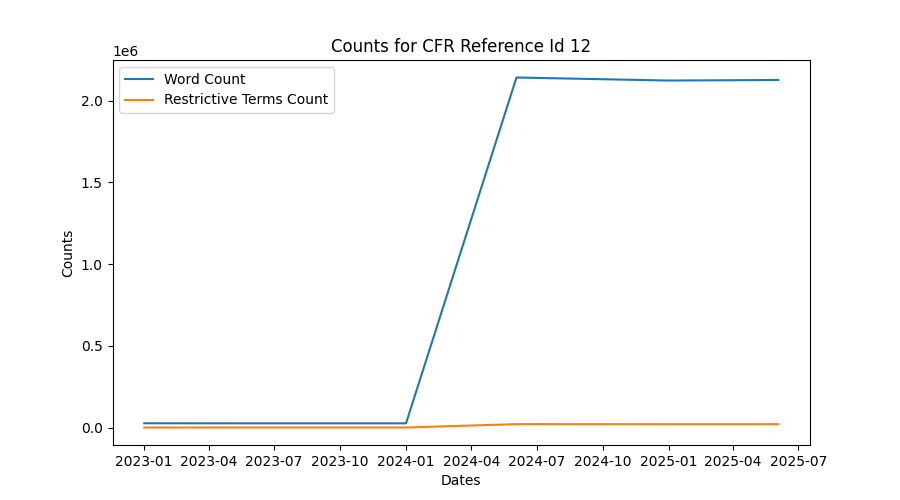

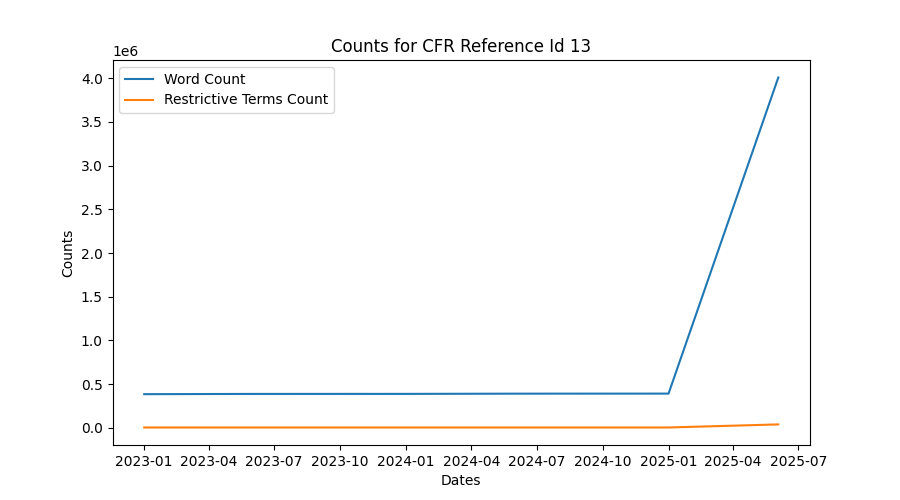

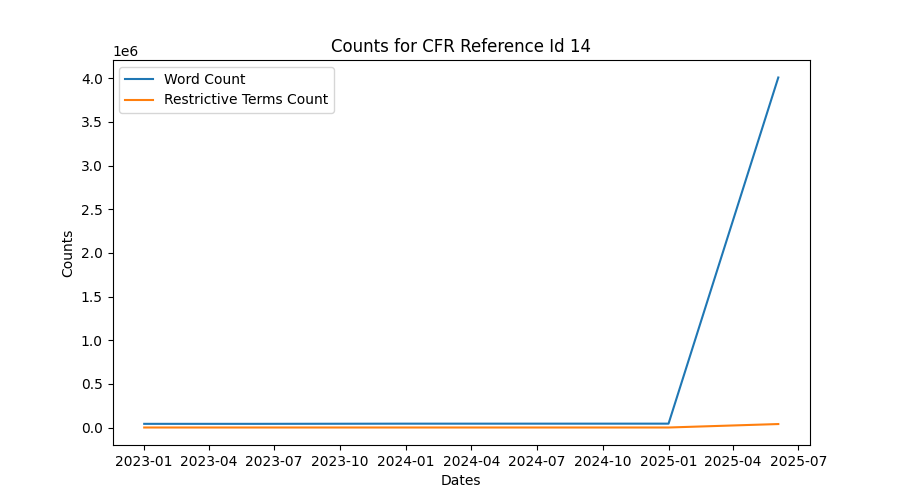

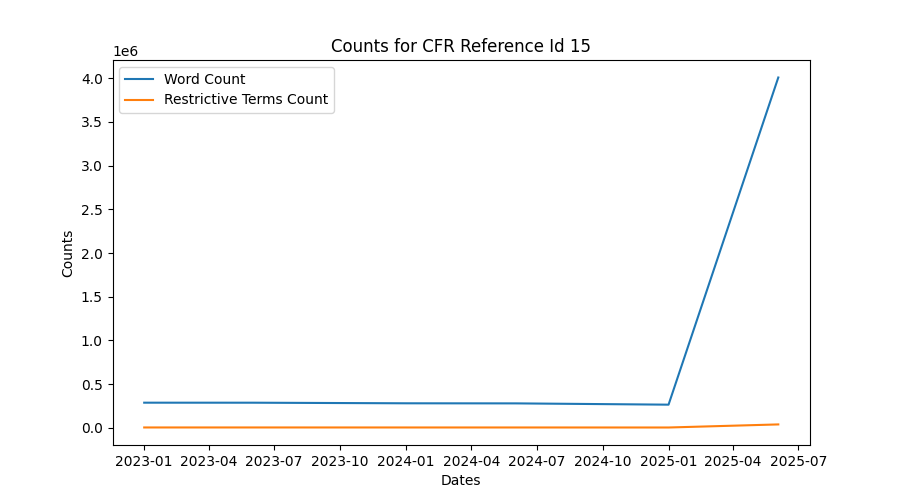

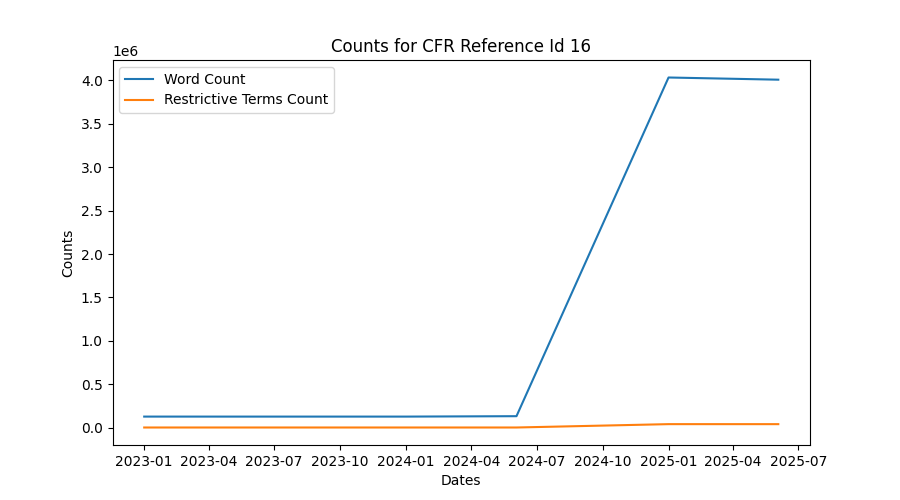

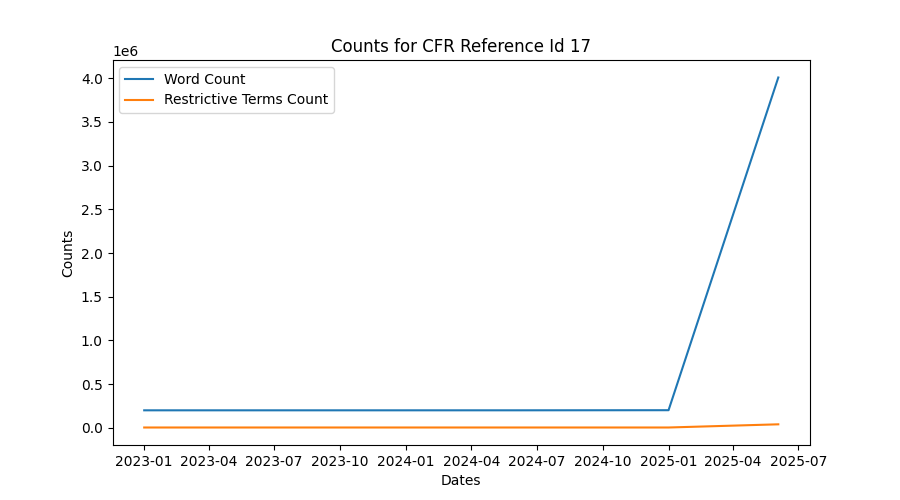

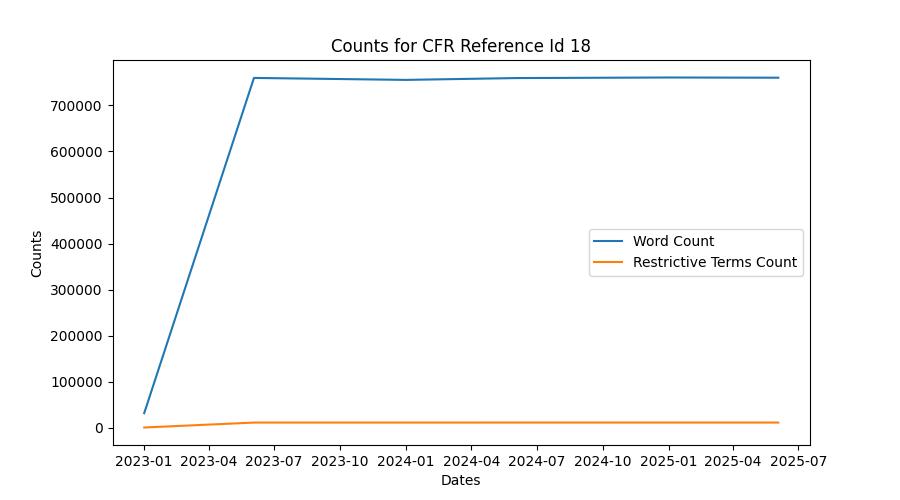

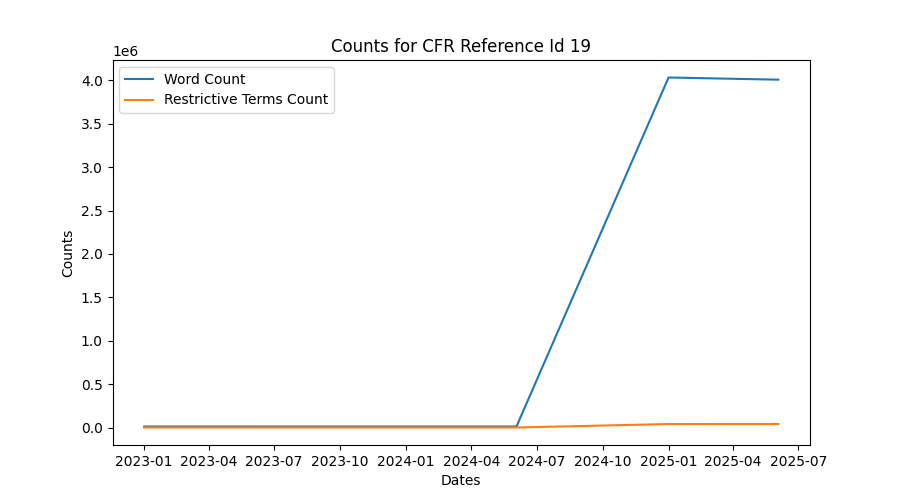

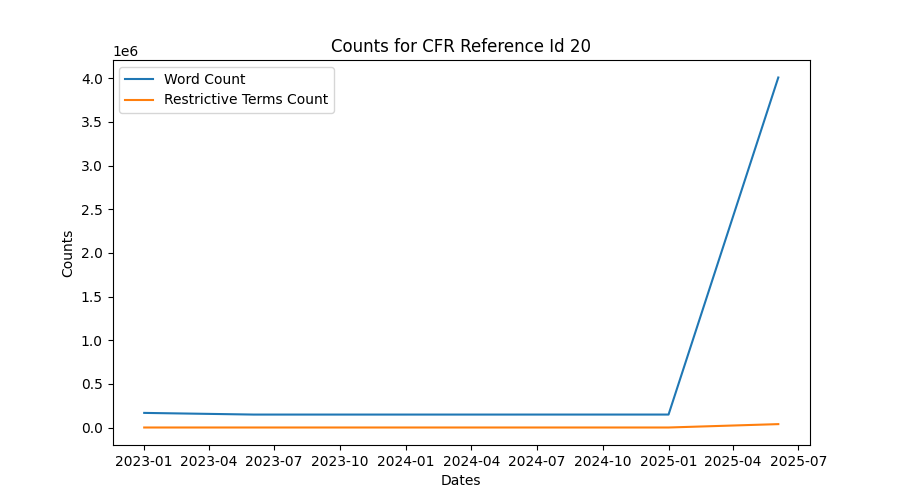

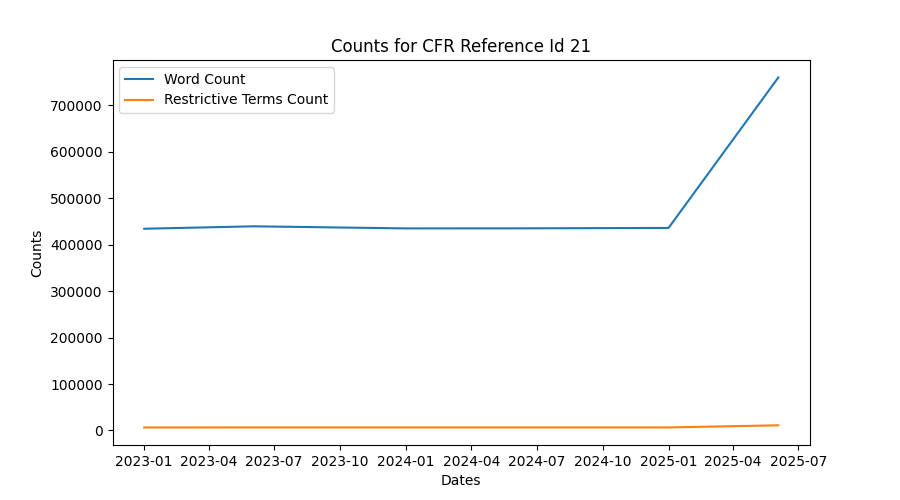

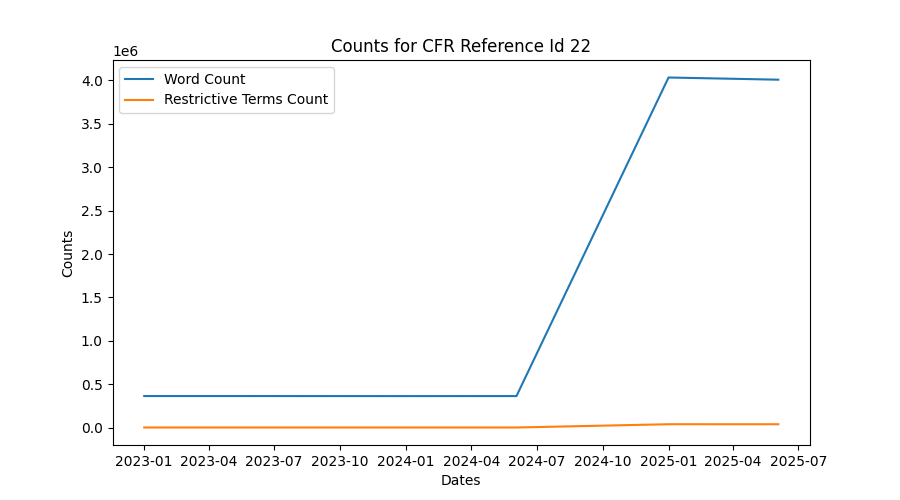

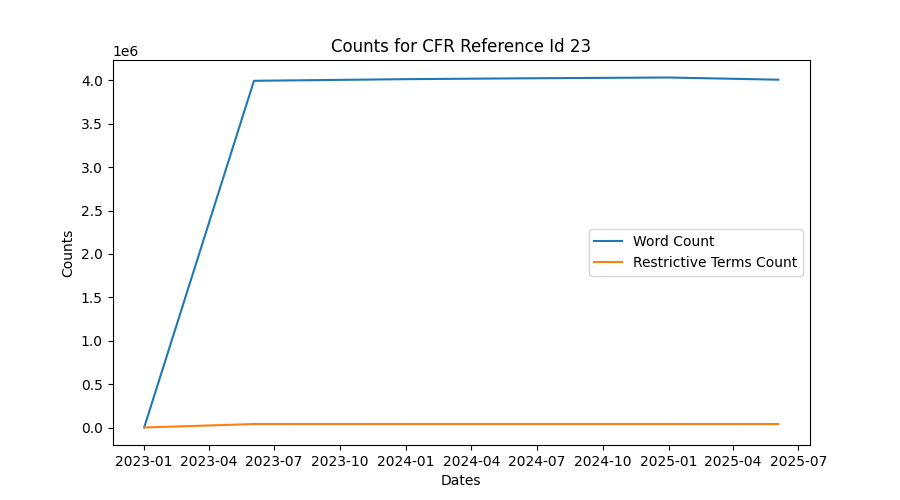

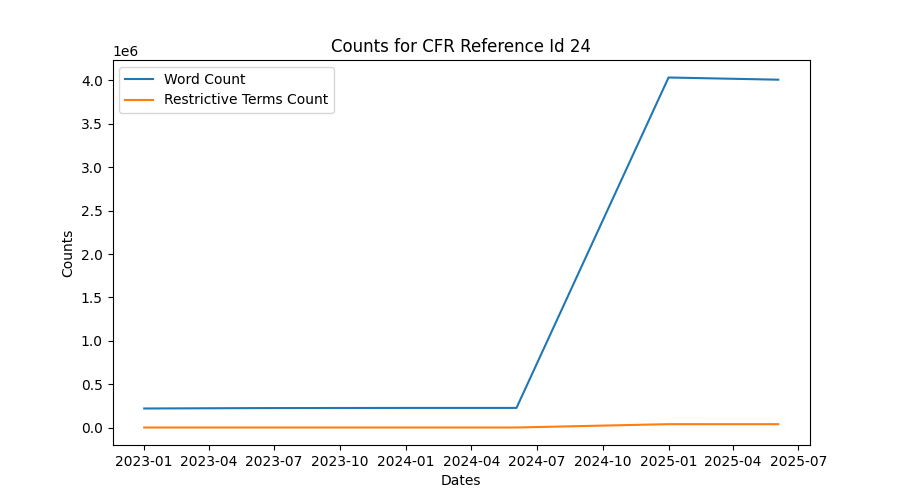

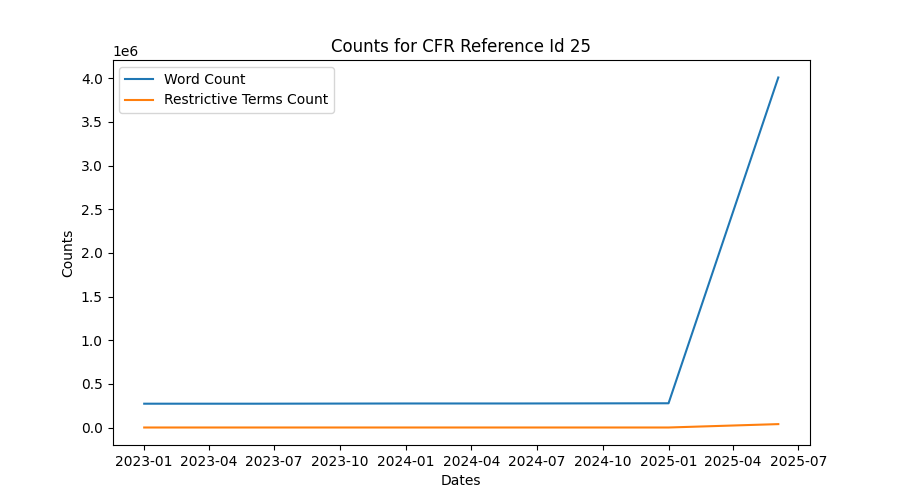

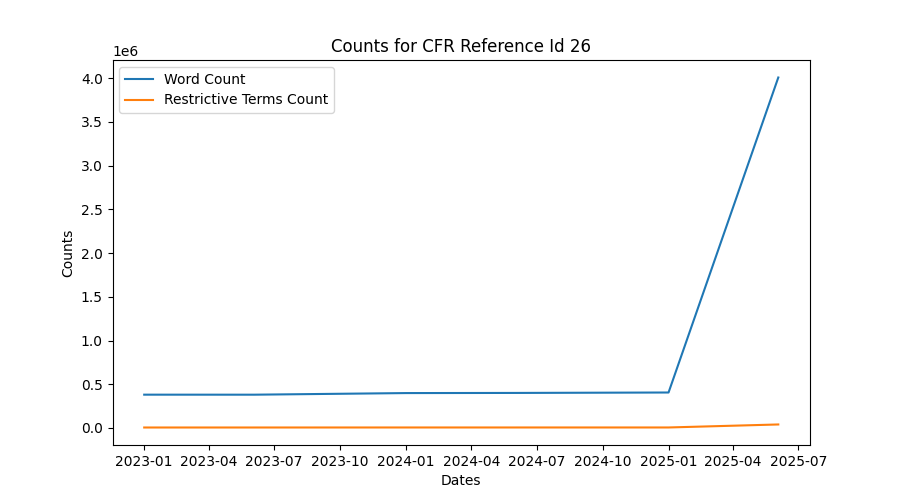

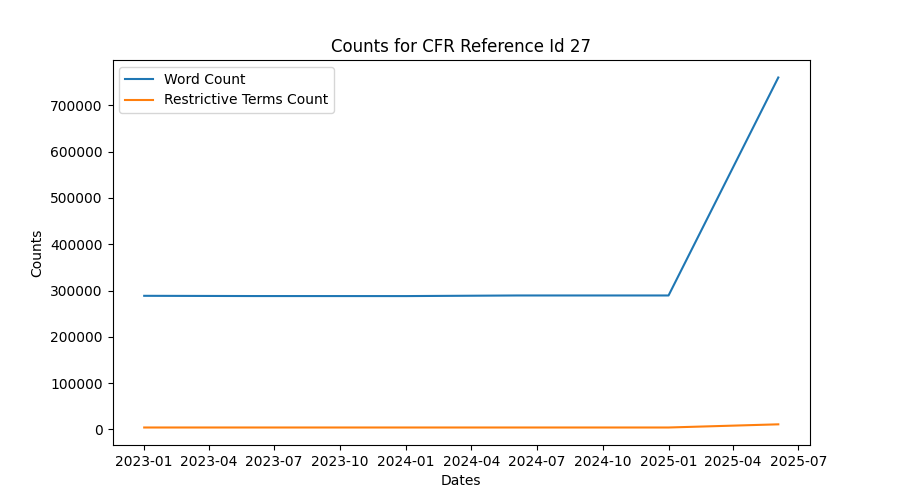

/var/folders/b6/mty8z4pn21vcb02l2tmrc22m0000gn/T/ipykernel_21097/3756341265.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(9, 5))


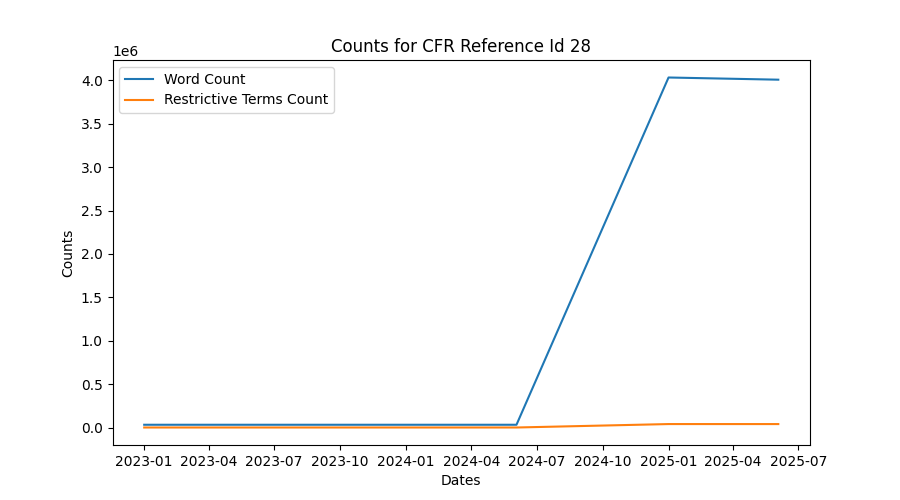

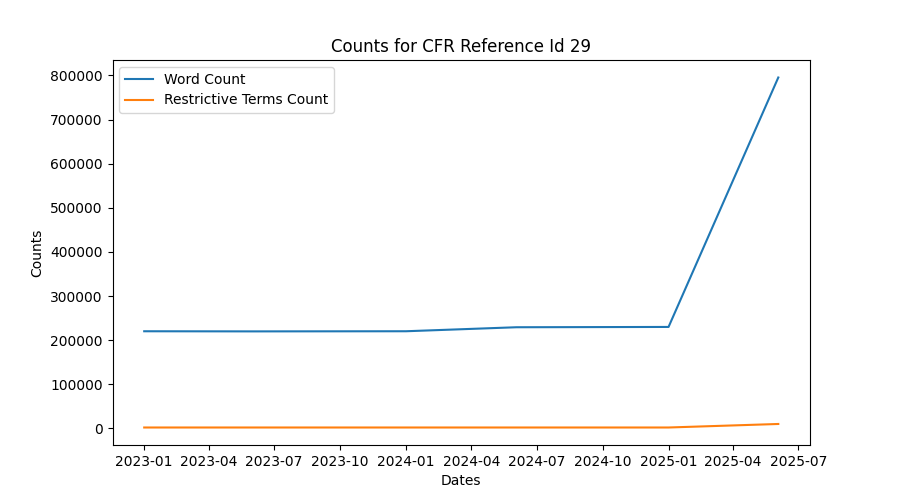

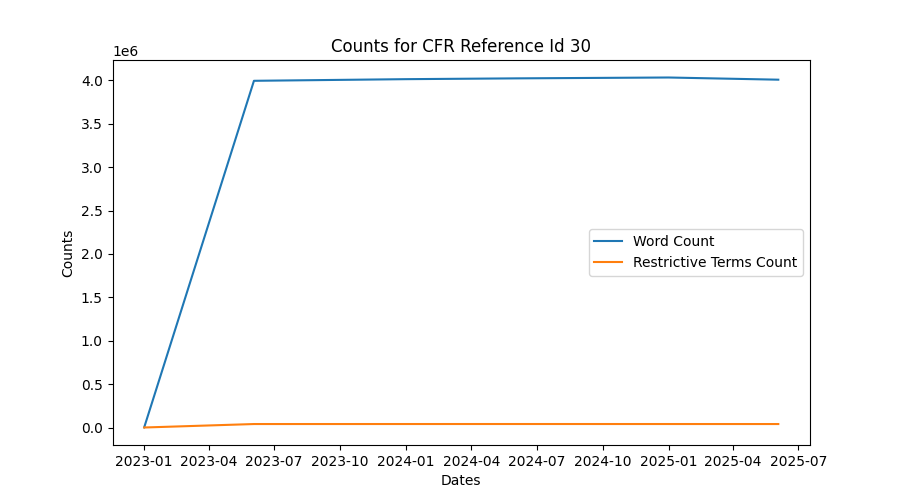

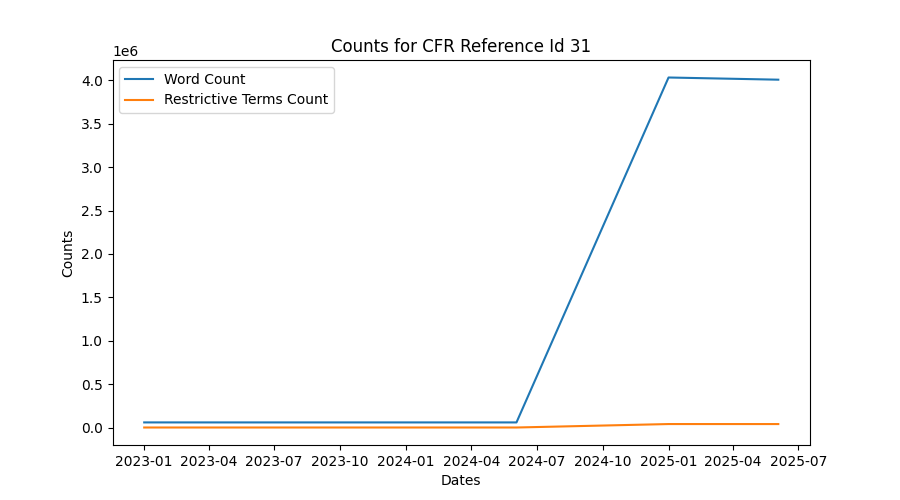

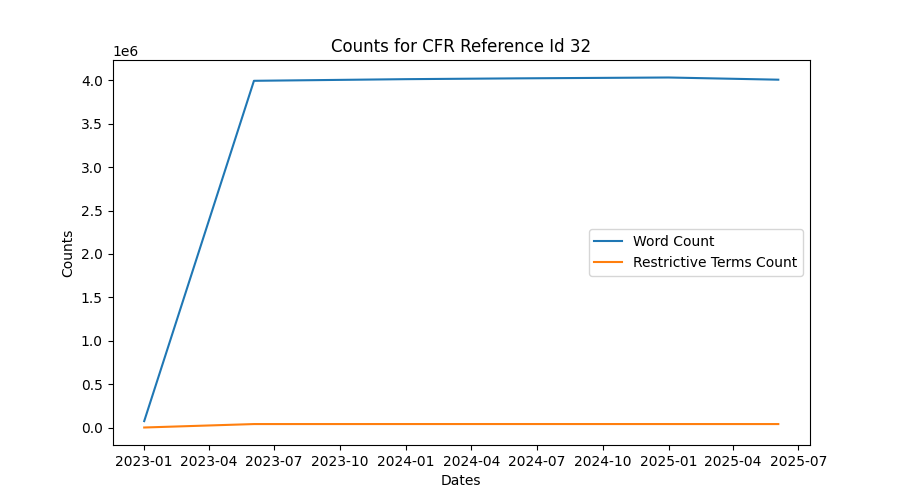

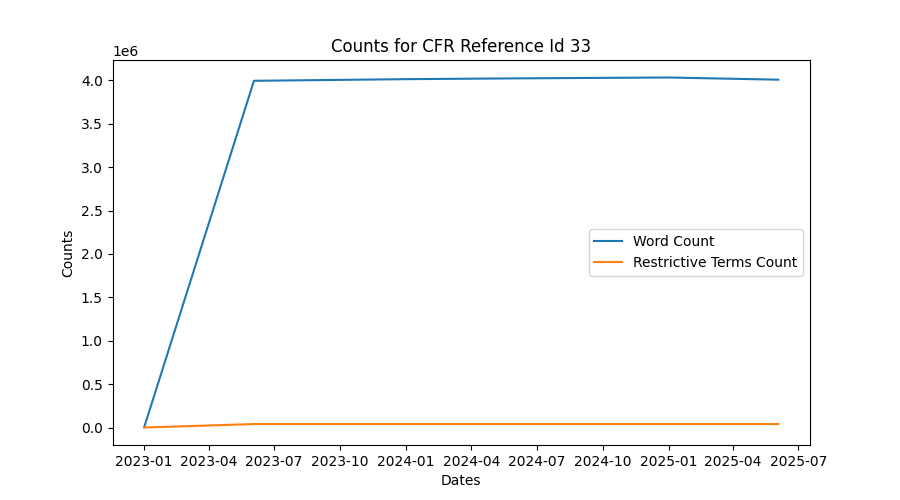

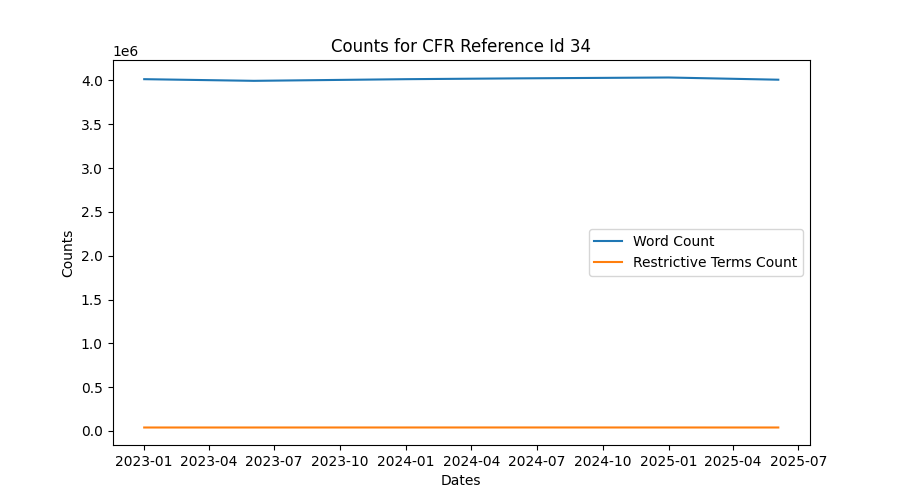

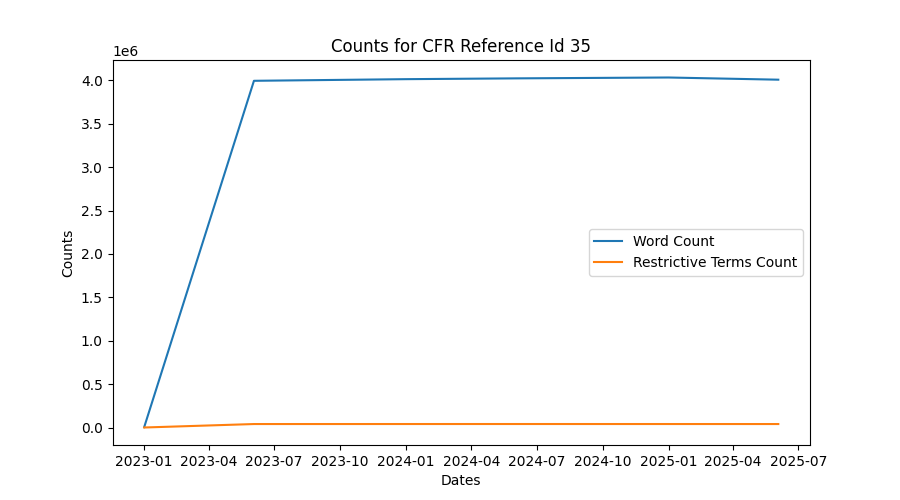

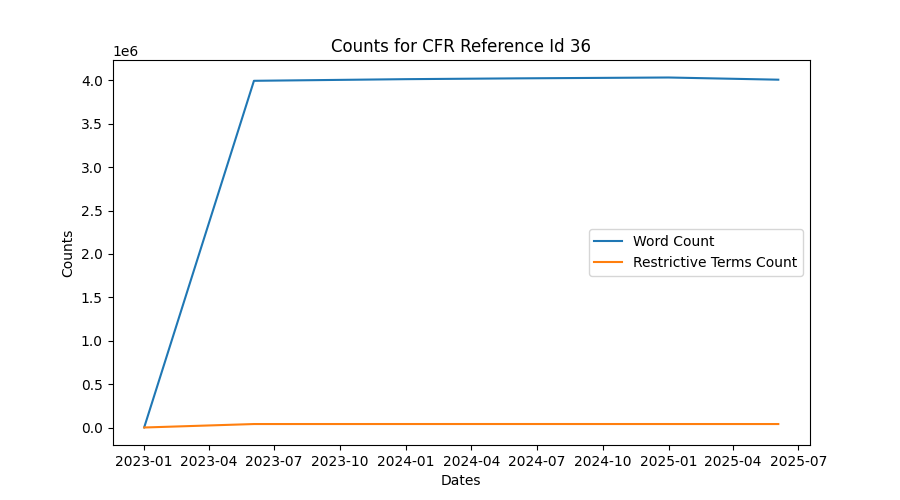

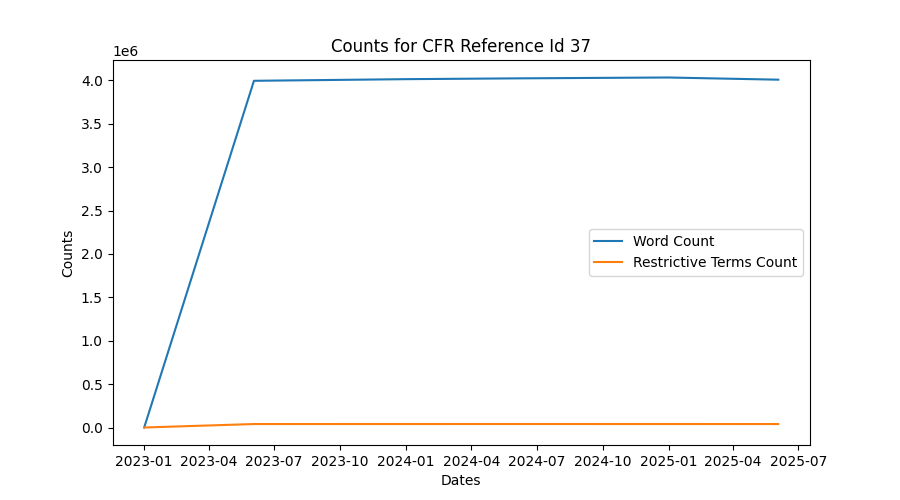

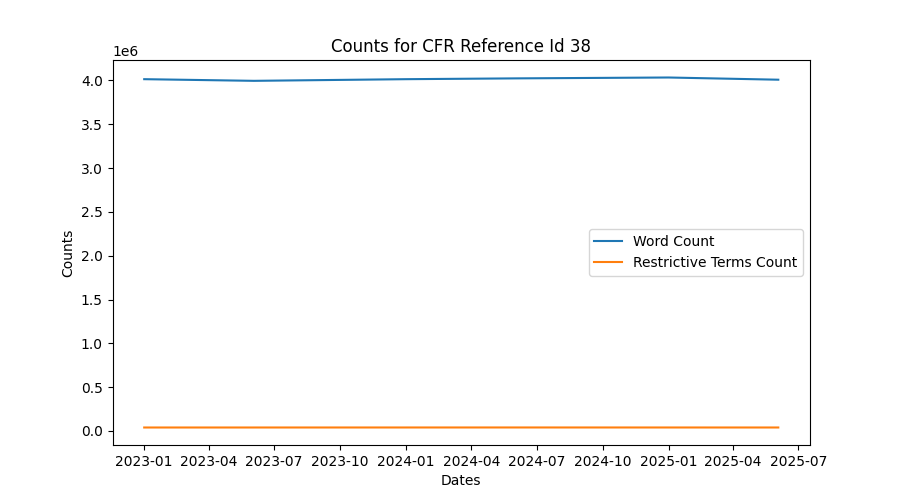

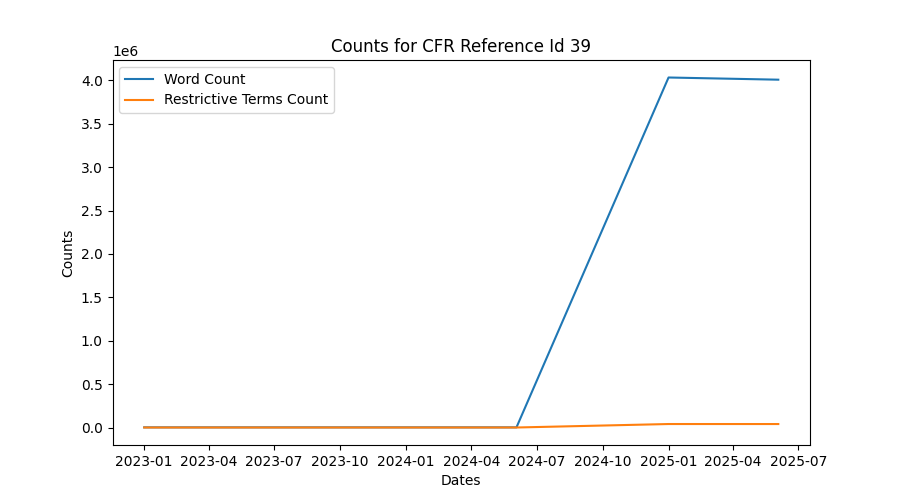

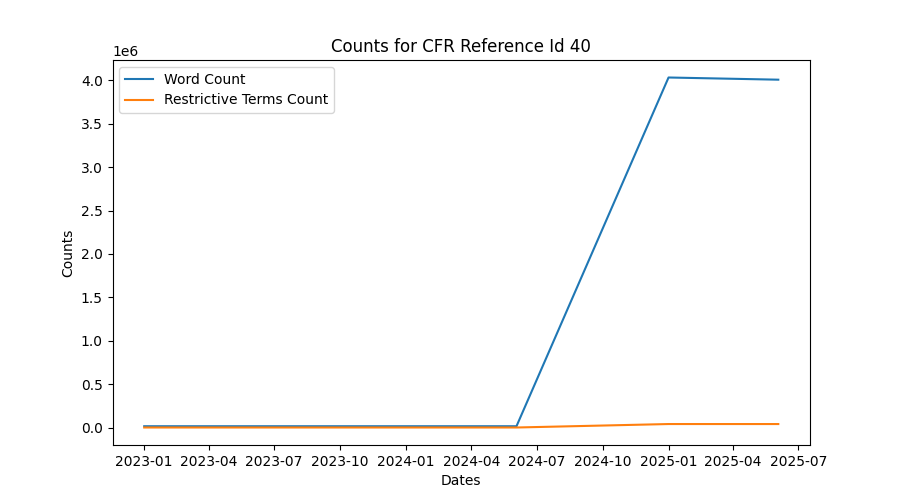

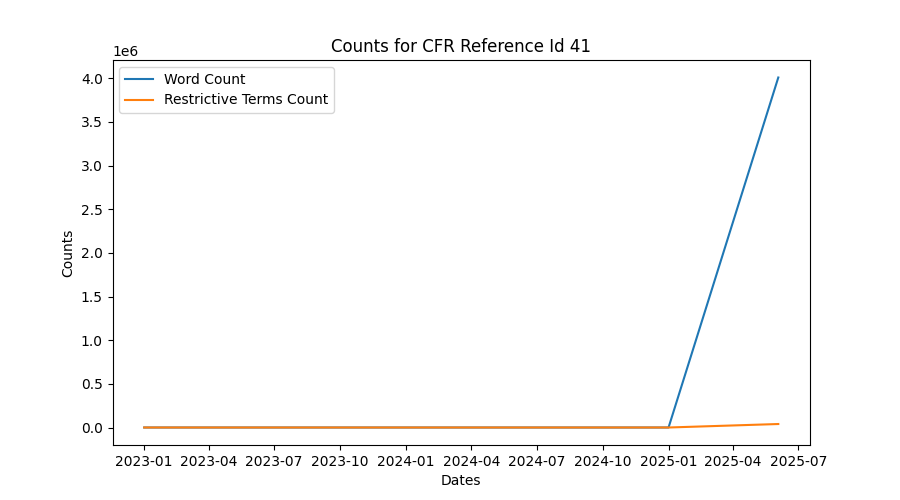

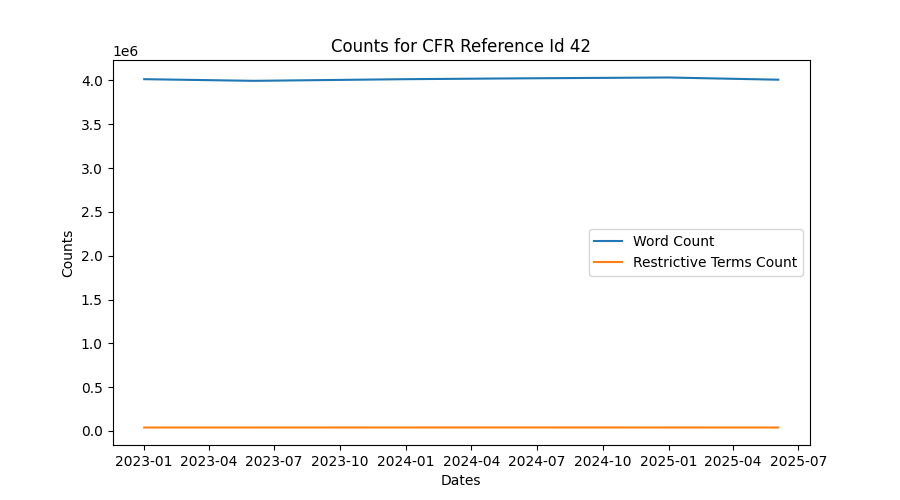

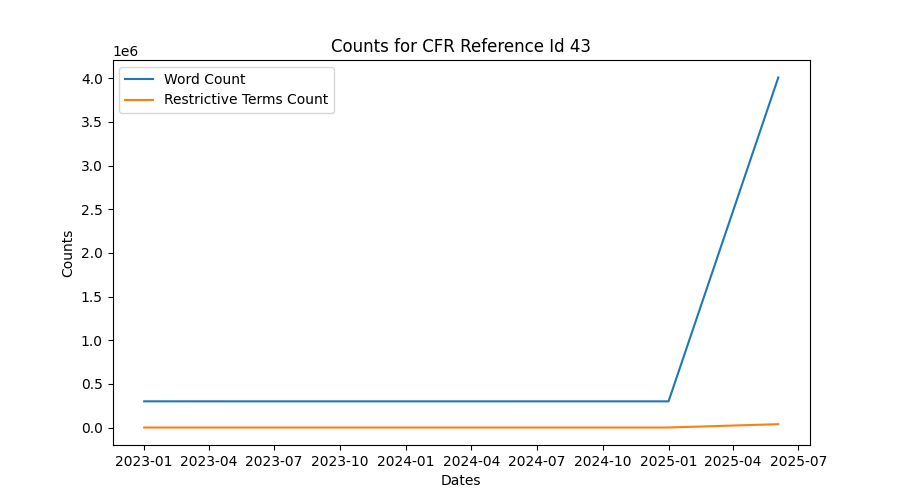

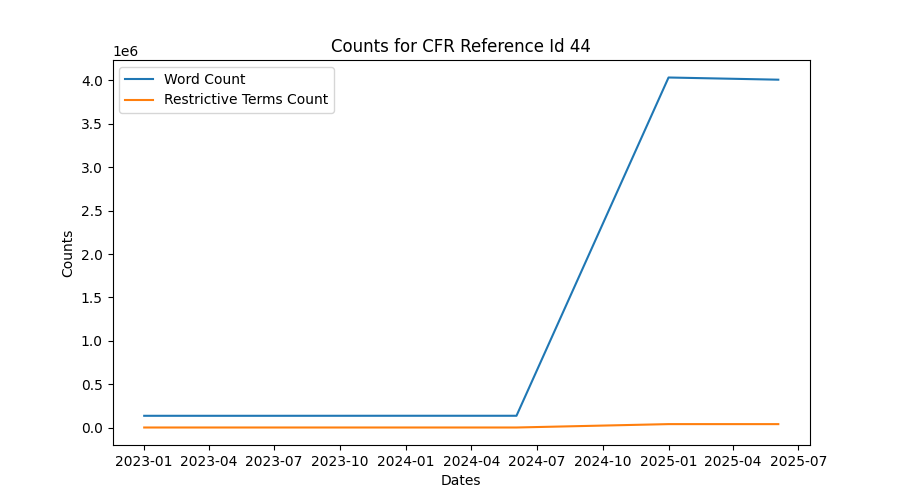

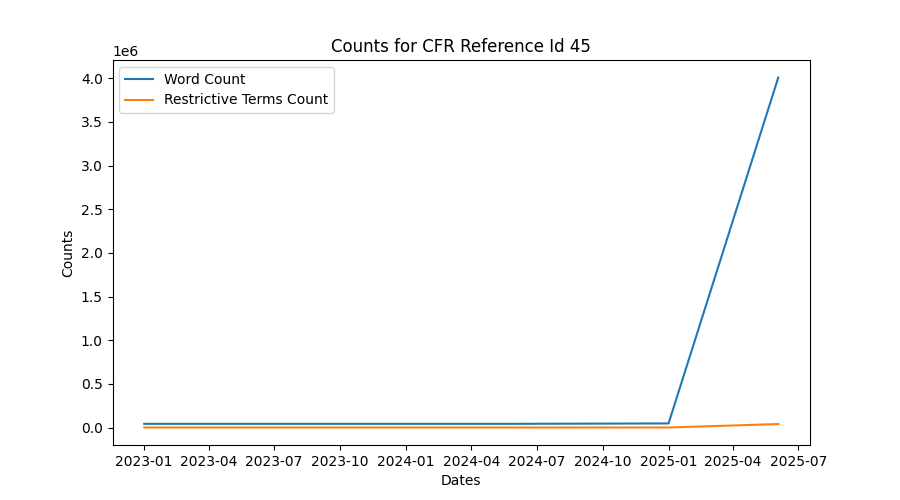

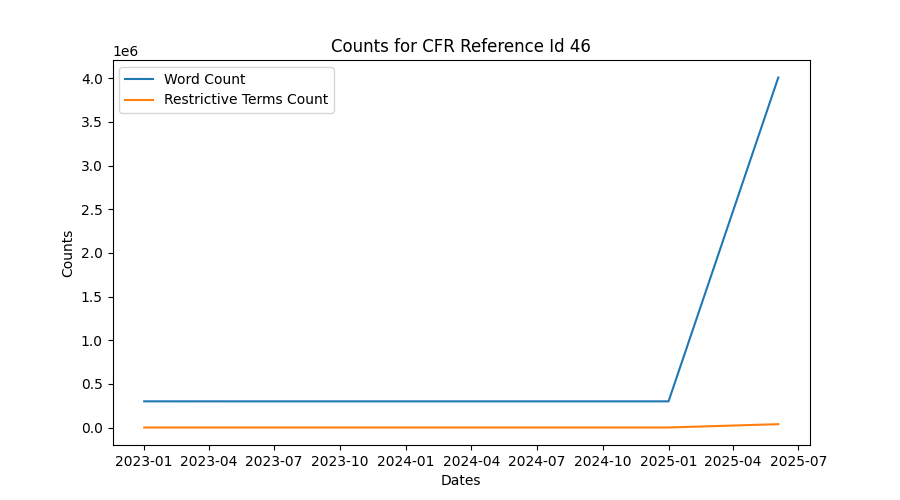

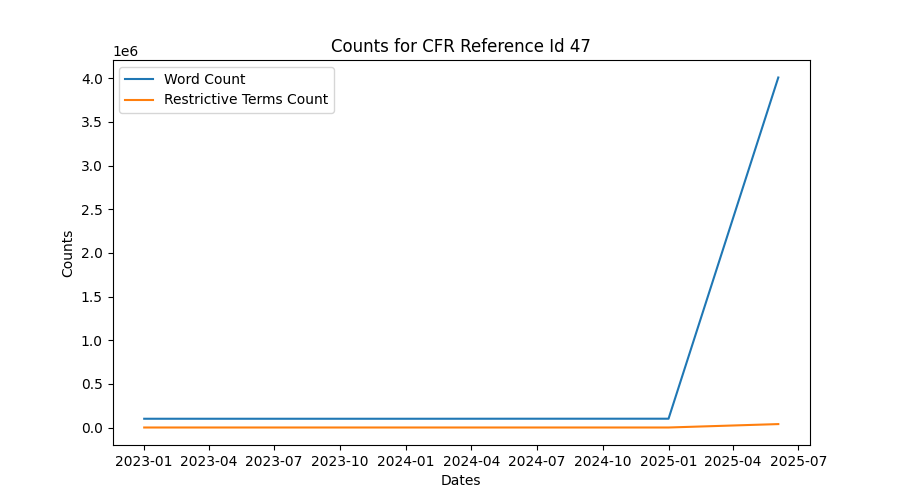

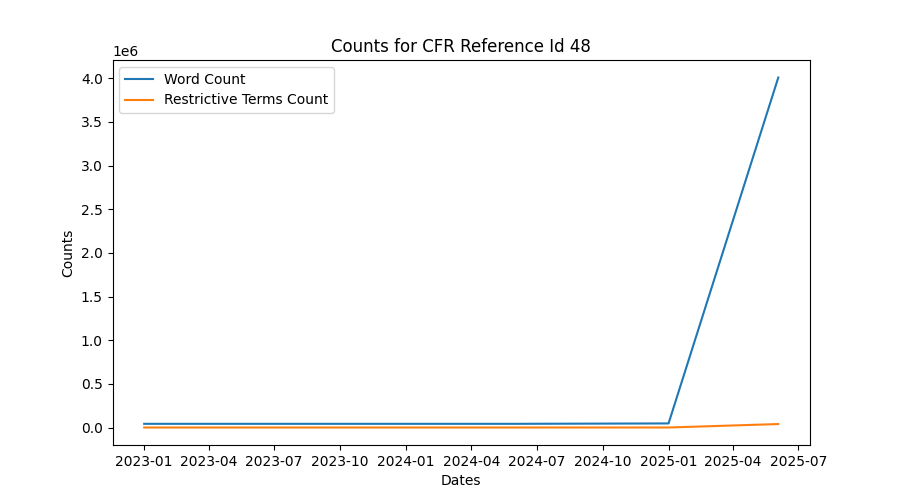

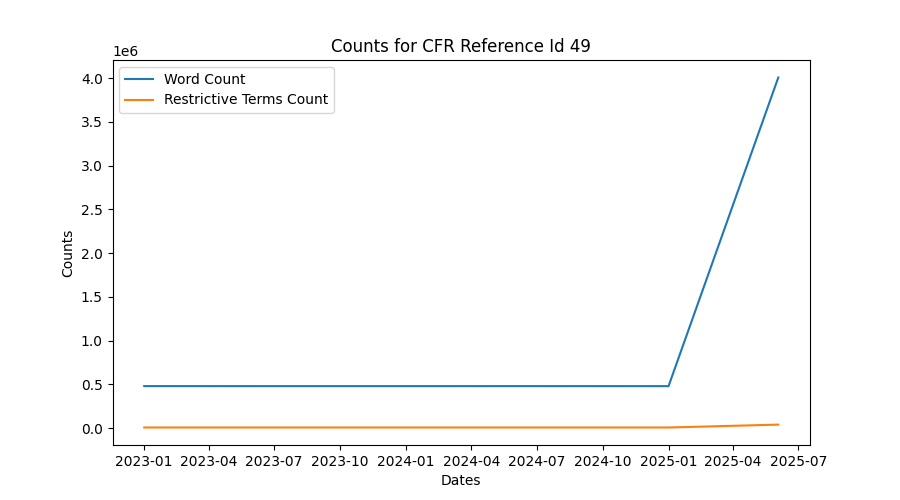

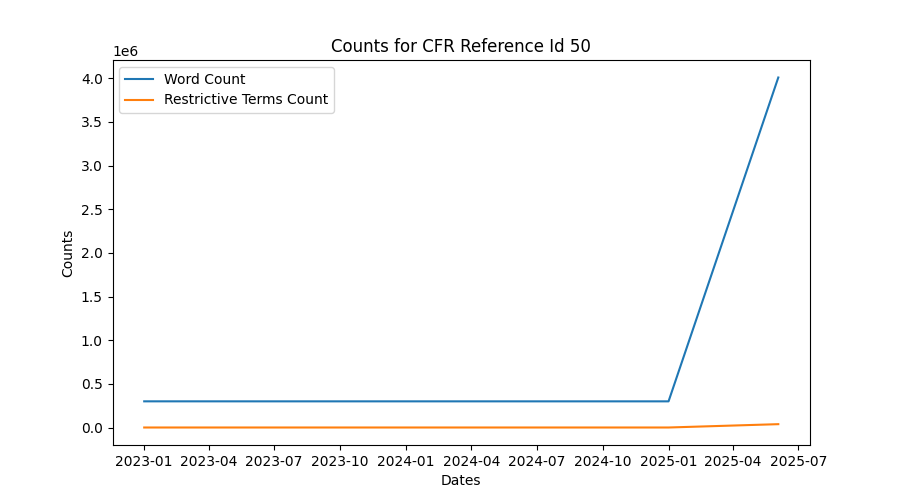

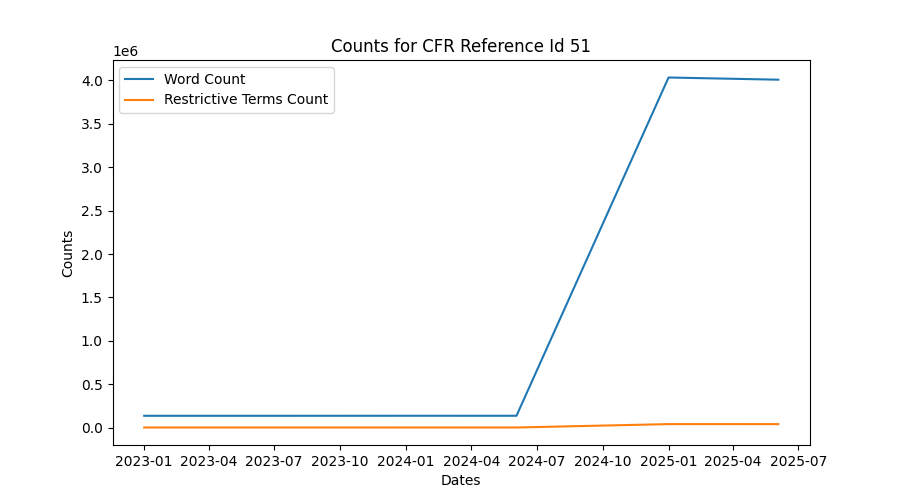

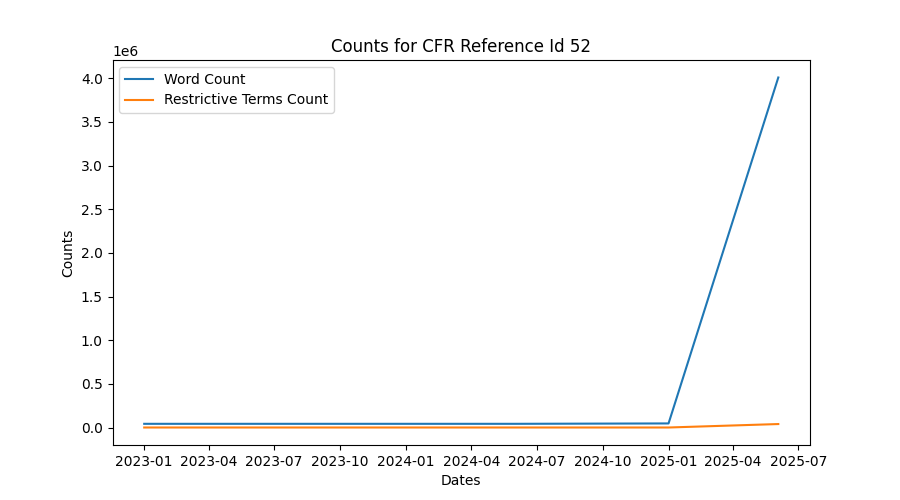

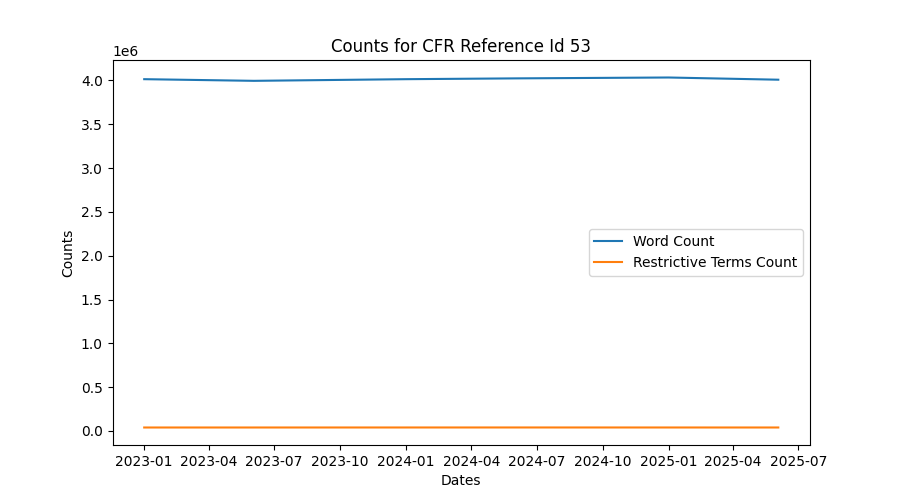

In [5]:
for key, value in insights_by_reference_id.items():
    value.sort(key=lambda d: d["date"])
    y_word_counts = [d.get("word_count") for d in value]
    y_restrictive_terms_counts = [d.get("restrictive_terms_count") for d in value]
    x_dates = pd.to_datetime([d.get("date") for d in value])
    plt.figure(figsize=(9, 5))
    plt.plot(x_dates, y_word_counts)
    plt.plot(x_dates, y_restrictive_terms_counts)
    plt.title("Counts for CFR Reference Id " + str(key))
    plt.xlabel("Dates")
    plt.ylabel("Counts")
    plt.legend(["Word Count", "Restrictive Terms Count"])
    plt.show()